Steady- bold textstate Ligand-Receptor inference

In [ ]:
pip install liana

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.3/558.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 88.8 MB/s eta 0:00:00
  Created wheel for docrep: filename=docrep-0.3.2-py3-none-any.whl size=19876 sha256=3812d48b83c92c0f385b9b96a60ab77c8601a9e8bdda2e8ed538a3b401b1baa3
  Stored in directory: /root/.cache/pip/wheels/d6/19/ee/0a6a1793d91c449563b49ccab57ce52da3e6fab7614836bd8c
Successfully built docrep


In [ ]:
# import liana
import liana as li
# needed for visualization and toy data
import scanpy as sc

In [ ]:
adata = sc.datasets.pbmc68k_reduced()

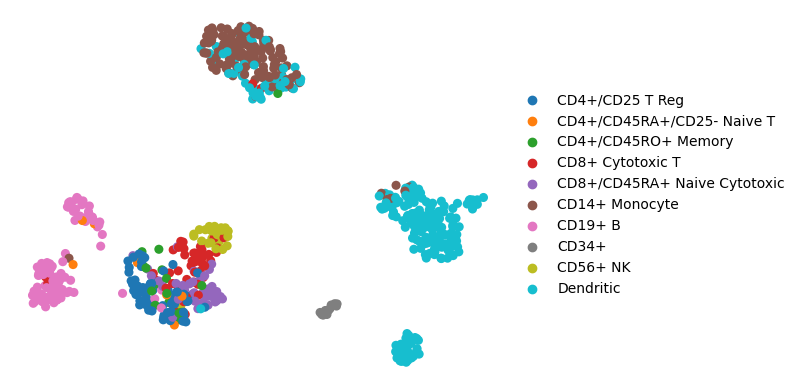

In [ ]:
sc.pl.umap(adata, color='bulk_labels', title='', frameon=False)

INFO

We have the overall gene expression for each cell.

*-> What to do with that data?*
One thing to do is to **group the cells together by gene expression** (microglia have different gene expressions than neurons, astrocytes, etc., as different proteins have different structures)
*-> Can we group cells together by similar gene expression patterns?*
Yes. The above graph does something similar.

**Clustering** is working out which cells are close together in a space in order to find genes with similar expression patterns. After clustering, each cell has a label with which cluster it is in, and the cluster labels identify which cells have similar expression patterns. This data set is very high dimensional.

**The above graph is a visualization of clustering.**

It's very hard to vsiualize single-cell data in 2d. UMAP is an algorithm that takes this form of data and tries to represent it in 2d such that cells with similar expression patterns are close together and cells with different expression patterns are far apart.

LIANA typically uses log1p-transformed counts matrix, which is...

To look at what's going on in cells, one can look at changes in protein expression, which is difficult so it's easier to look at levels of RNA as they translate into proteins.

microglia changes behavior by making proteins (by making RNA). By looking at RNA sequencing data, we can look at which genes are being expressed.

The data we are using in the actual project (not the toy data in this tutorial) is from the cells we want to measure the expression in, with the cells put in a machine that extracts all of the RNA and attaches a cell indictor barcode to the RNA molecules. You can then see the distribution of RNA molecules per cell (single cell) and in the brain in general. The single cell data is what we are using for the project (distribution of RNA on a single-cell level).

Our data will be a big matrix of A x B, A being cells (each column a cell), and B being genes (each row a gene), and the matrix shows how much of a certain gene is in a particular cell (which one is r/c is arbitrary right now).

In [ ]:
adata.raw.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 174400 stored elements and shape (700, 765)>

In [ ]:
li.mt.show_methods()

,Method Name,Magnitude Score,Specificity Score,Reference
0,CellPhoneDB,lr_means,cellphone_pvals,"Efremova, M., Vento-Tormo, M., Teichmann, S.A...."
0,Connectome,expr_prod,scaled_weight,"Raredon, M.S.B., Yang, J., Garritano, J., Wang..."
0,log2FC,None,lr_logfc,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,NATMI,expr_prod,spec_weight,"Hou, R., Denisenko, E., Ong, H.T., Ramilowski,..."
0,SingleCellSignalR,lrscore,None,"Cabello-Aguilar, S., Alame, M., Kon-Sun-Tack, ..."
0,Rank_Aggregate,magnitude_rank,specificity_rank,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,Geometric Mean,lr_gmeans,gmean_pvals,CellPhoneDBv2's permutation approach applied t...
0,scSeqComm,inter_score,None,"Baruzzo, G., Cesaro, G., Di Camillo, B. 2022. ..."
0,CellChat,lr_probs,cellchat_pvals,"Jin, S., Guerrero-Juarez, C.F., Zhang, L., Cha..."


In [ ]:
# import liana's rank_aggregate
from liana.mt import rank_aggregate

In [ ]:
rank_aggregate.__call__

In [ ]:
rank_aggregate.describe()

Rank_Aggregate returns `magnitude_rank`, `specificity_rank`. magnitude_rank and specificity_rank respectively represent an aggregate of the `magnitude`- and `specificity`-related scoring functions from the different methods.


In [ ]:
# import all individual methods
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean

In [ ]:
# run cellphonedb
cellphonedb(adata,
            groupby='bulk_labels',
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name='consensus',
            expr_prop=0.1,
            verbose=True, key_added='cpdb_res')

/usr/local/lib/python3.12/dist-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/usr/local/lib/python3.12/dist-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


Generating ligand-receptor stats for 700 samples and 43 features


100%|██████████| 1000/1000 [00:09<00:00, 107.30it/s]


In [ ]:
# by default, liana's output is saved in place:
adata.uns['cpdb_res'].head()

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
482,HLA-DRA,HLA-DRA,4.537684,0.995833,CD4,CD4,0.612842,0.421053,Dendritic,CD4+/CD45RO+ Memory,2.575263,0.0
321,HLA-DRA,HLA-DRA,4.537684,0.995833,CD4,CD4,0.596125,0.500000,Dendritic,CD4+/CD45RA+/CD25- Naive T,2.566905,0.0
989,HLA-DRA,HLA-DRA,4.537684,0.995833,CD4,CD4,0.483977,0.302326,Dendritic,CD14+ Monocyte,2.510830,0.0
651,HLA-DRA,HLA-DRA,4.537684,0.995833,LAG3,LAG3,0.399500,0.240741,Dendritic,CD8+ Cytotoxic T,2.468592,0.0
1392,HLA-DRA,HLA-DRA,4.537684,0.995833,CD4,CD4,0.373671,0.270833,Dendritic,Dendritic,2.455678,0.0


Dotplot

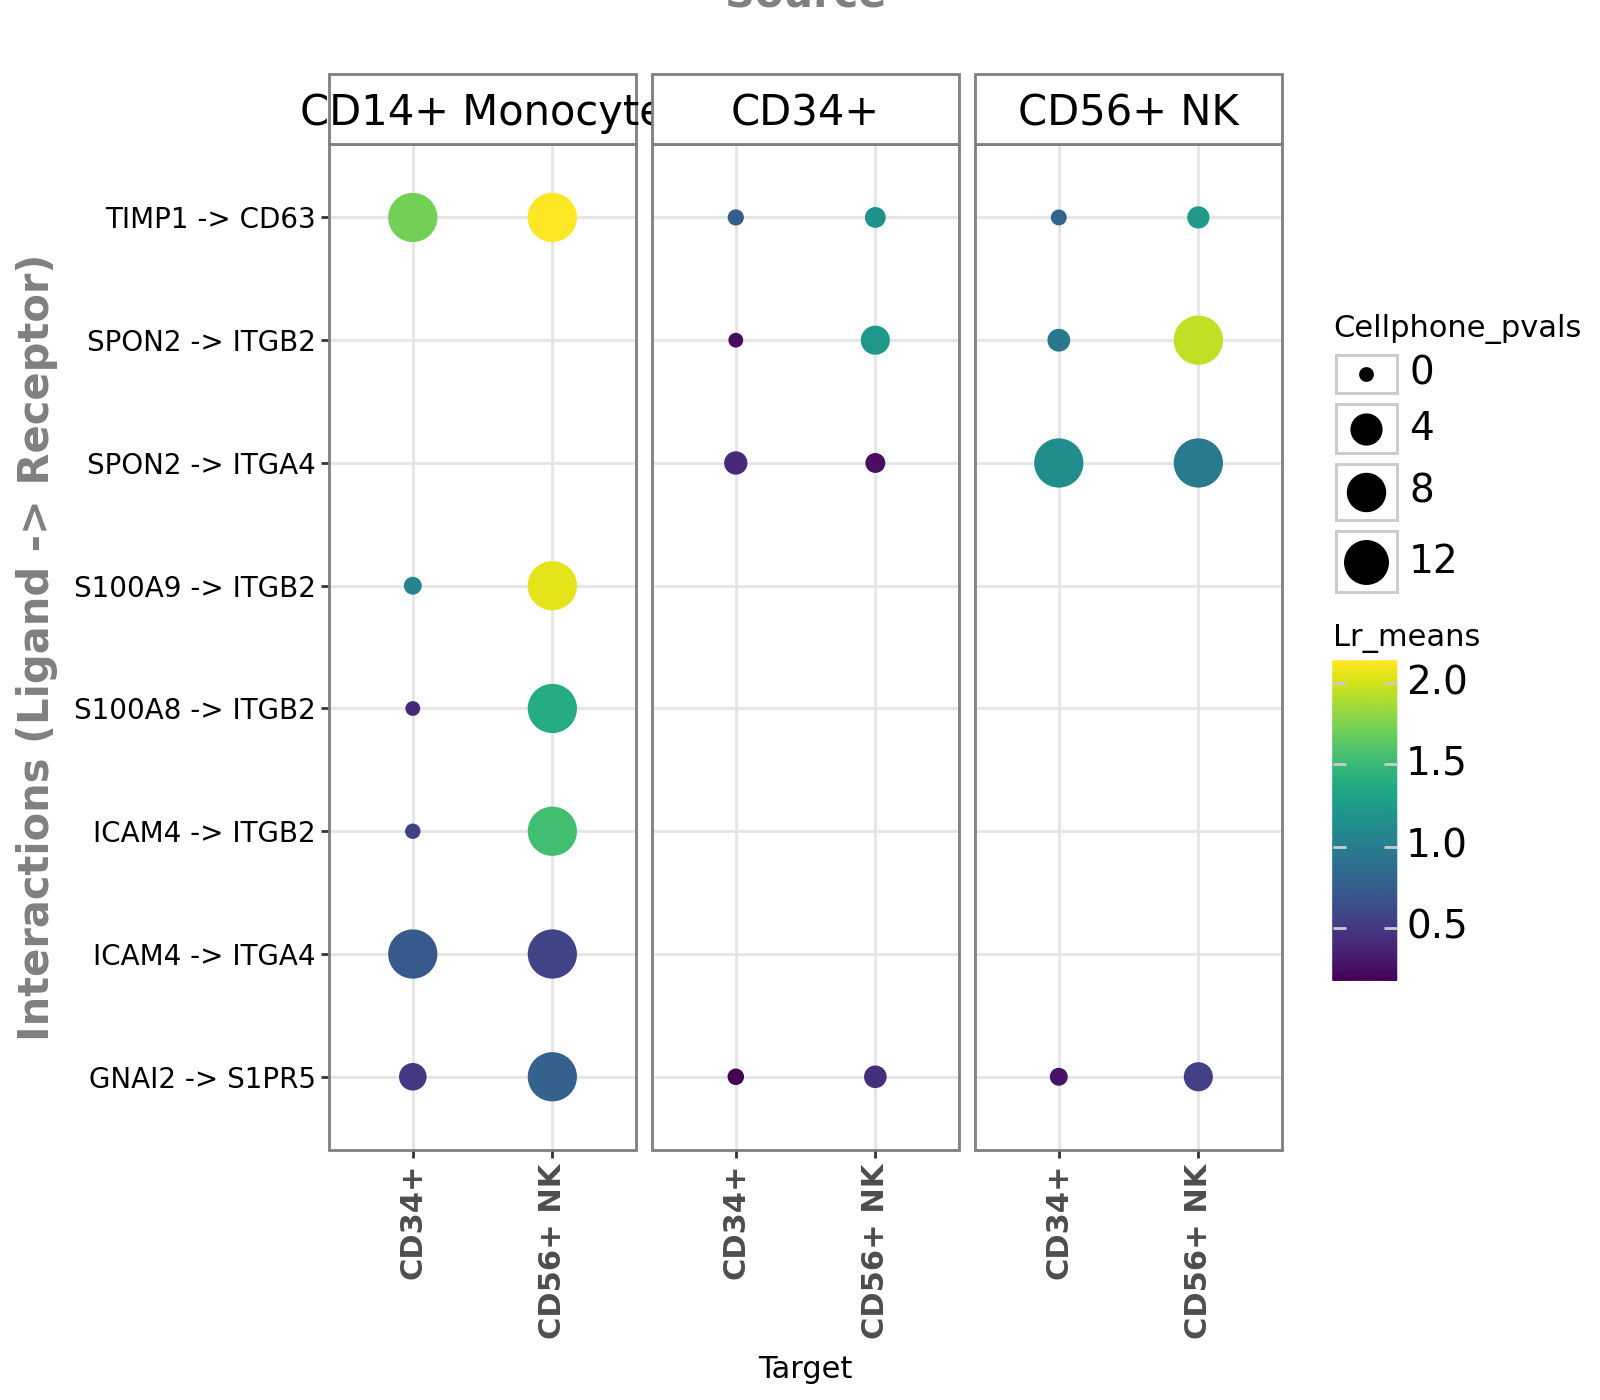

In [ ]:
li.pl.dotplot(adata = adata,
              colour='lr_means',
              size='cellphone_pvals',
              inverse_size=True, # we inverse sign since we want small p-values to have large sizes
              source_labels=['CD34+', 'CD56+ NK', 'CD14+ Monocyte'],
              target_labels=['CD34+', 'CD56+ NK'],
              figure_size=(8, 7),
              # finally, since cpdbv2 suggests using a filter to FPs
              # we filter the pvals column to <= 0.05
              filter_fun=lambda x: x['cellphone_pvals'] <= 0.05,
              uns_key='cpdb_res' # uns_key to use, default is 'liana_res'
             )

/usr/local/lib/python3.12/dist-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


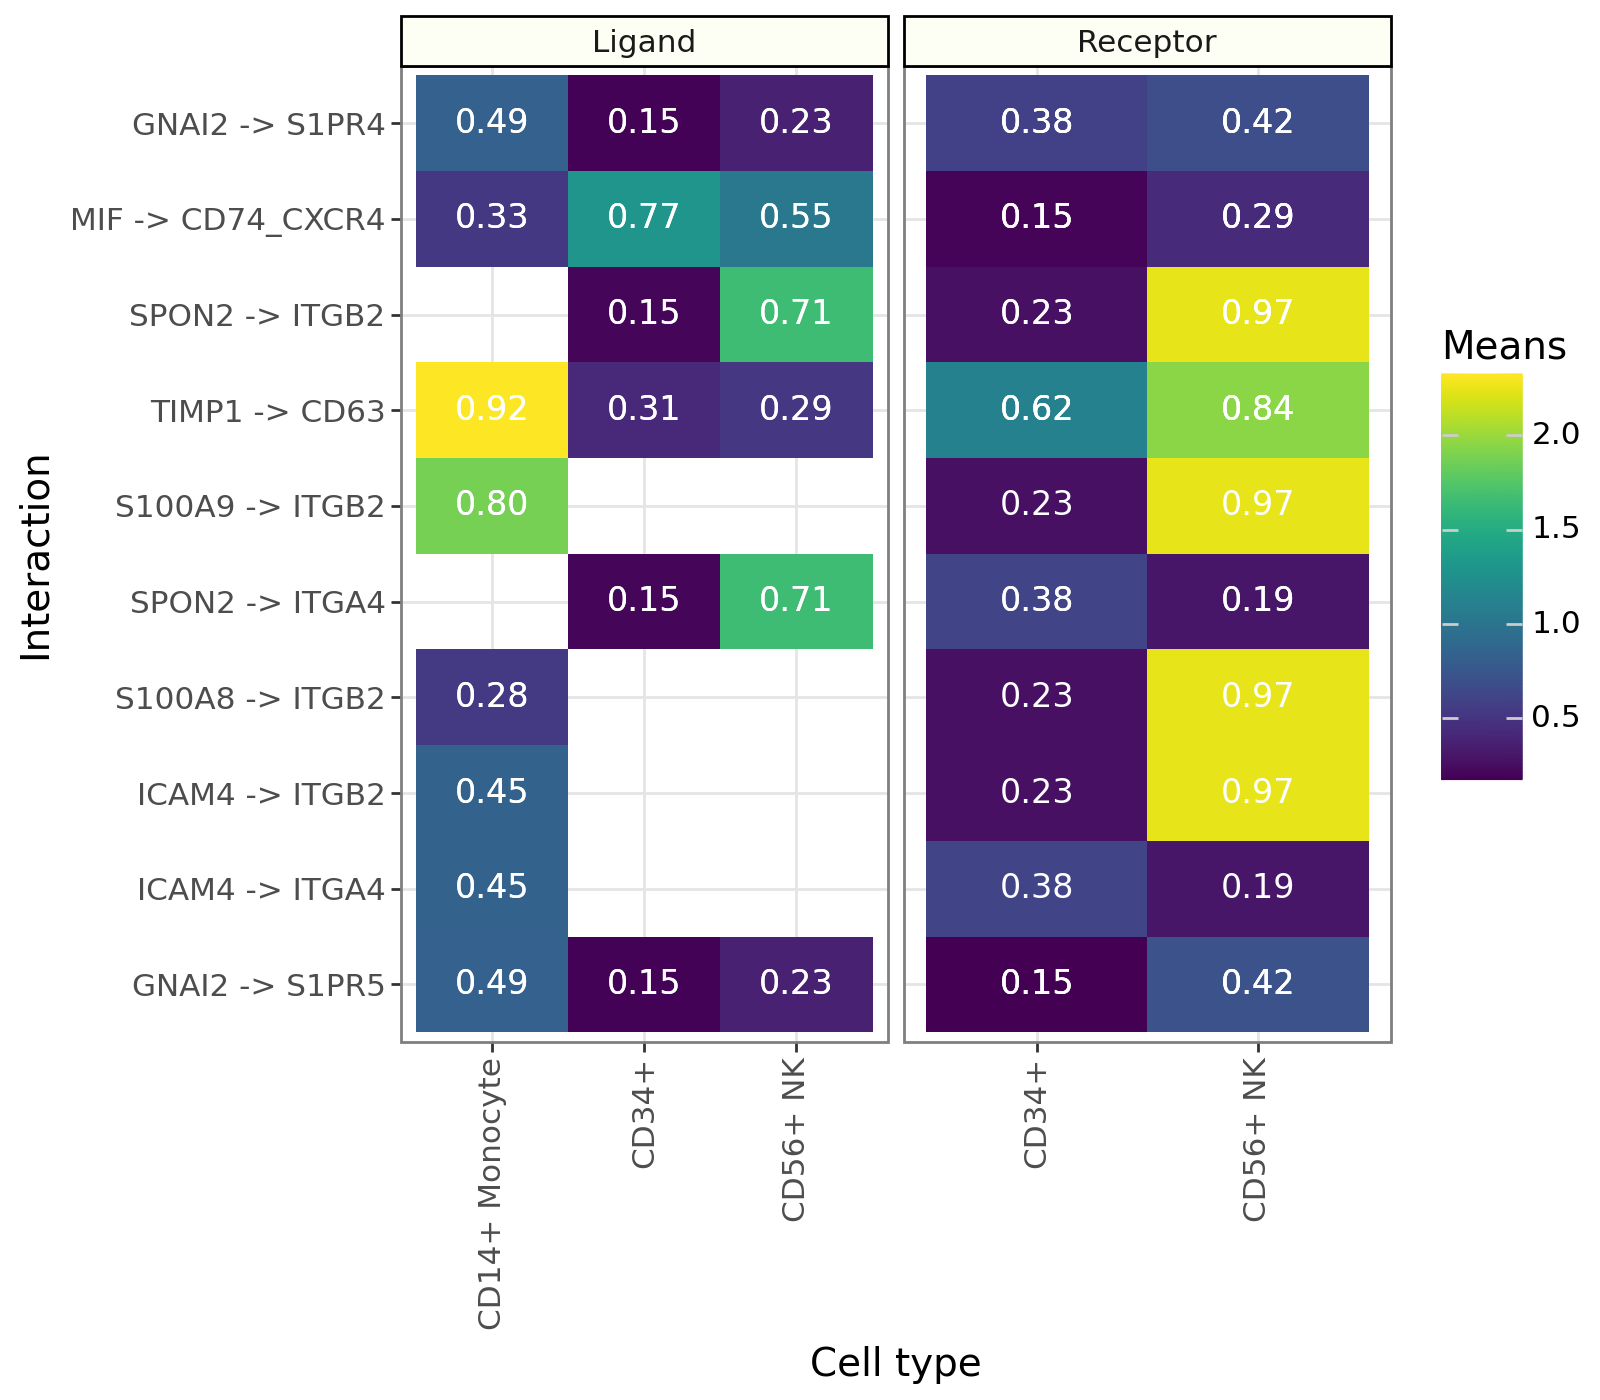

In [ ]:
my_plot = li.pl.tileplot(adata = adata,
                         # NOTE: fill & label need to exist for both
                         # ligand_ and receptor_ columns
                         fill='means',
                         label='props',
                         label_fun=lambda x: f'{x:.2f}',
                         top_n=10,
                         orderby='cellphone_pvals',
                         orderby_ascending=True,
                         source_labels=['CD34+', 'CD56+ NK', 'CD14+ Monocyte'],
                         target_labels=['CD34+', 'CD56+ NK'],
                         uns_key='cpdb_res', # NOTE: default is 'liana_res'
                         source_title='Ligand',
                         target_title='Receptor',
                         figure_size=(8, 7)
                         )
my_plot

INFO

Ligand in this case acts as a communication molecule that is emitted, which is detected by the receptors.
Look at ligand-producing gene expression and same for receptor, you could see (for example) that certain types of cells might express certain ligands and some might express certain receptors. If we know cell type 1 expresses a gene associated with a particular ligand and cell type 2 with a particular receptor, and that ligand-receptor pair is one we know to communicate, then we know that those cells might be communicating with one another.

We want to look at communication changes in Alzheimer's mice eventually.

In [ ]:
# Run rank_aggregate
li.mt.rank_aggregate(adata,
                     groupby='bulk_labels',
                     resource_name='consensus',
                     expr_prop=0.1,
                     verbose=True)

/usr/local/lib/python3.12/dist-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/usr/local/lib/python3.12/dist-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


Generating ligand-receptor stats for 700 samples and 43 features


/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
/usr/local/lib/python3.12/dist-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/usr/local/lib/python3.12/dist-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
/usr/local/lib/python3.12/dist-packages/liana/method/sc/_liana_pipe.py:296: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.


Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 1000/1000 [00:10<00:00, 97.40it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [ ]:
rank_aggregate.describe()

Rank_Aggregate returns `magnitude_rank`, `specificity_rank`. magnitude_rank and specificity_rank respectively represent an aggregate of the `magnitude`- and `specificity`-related scoring functions from the different methods.


/usr/local/lib/python3.12/dist-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


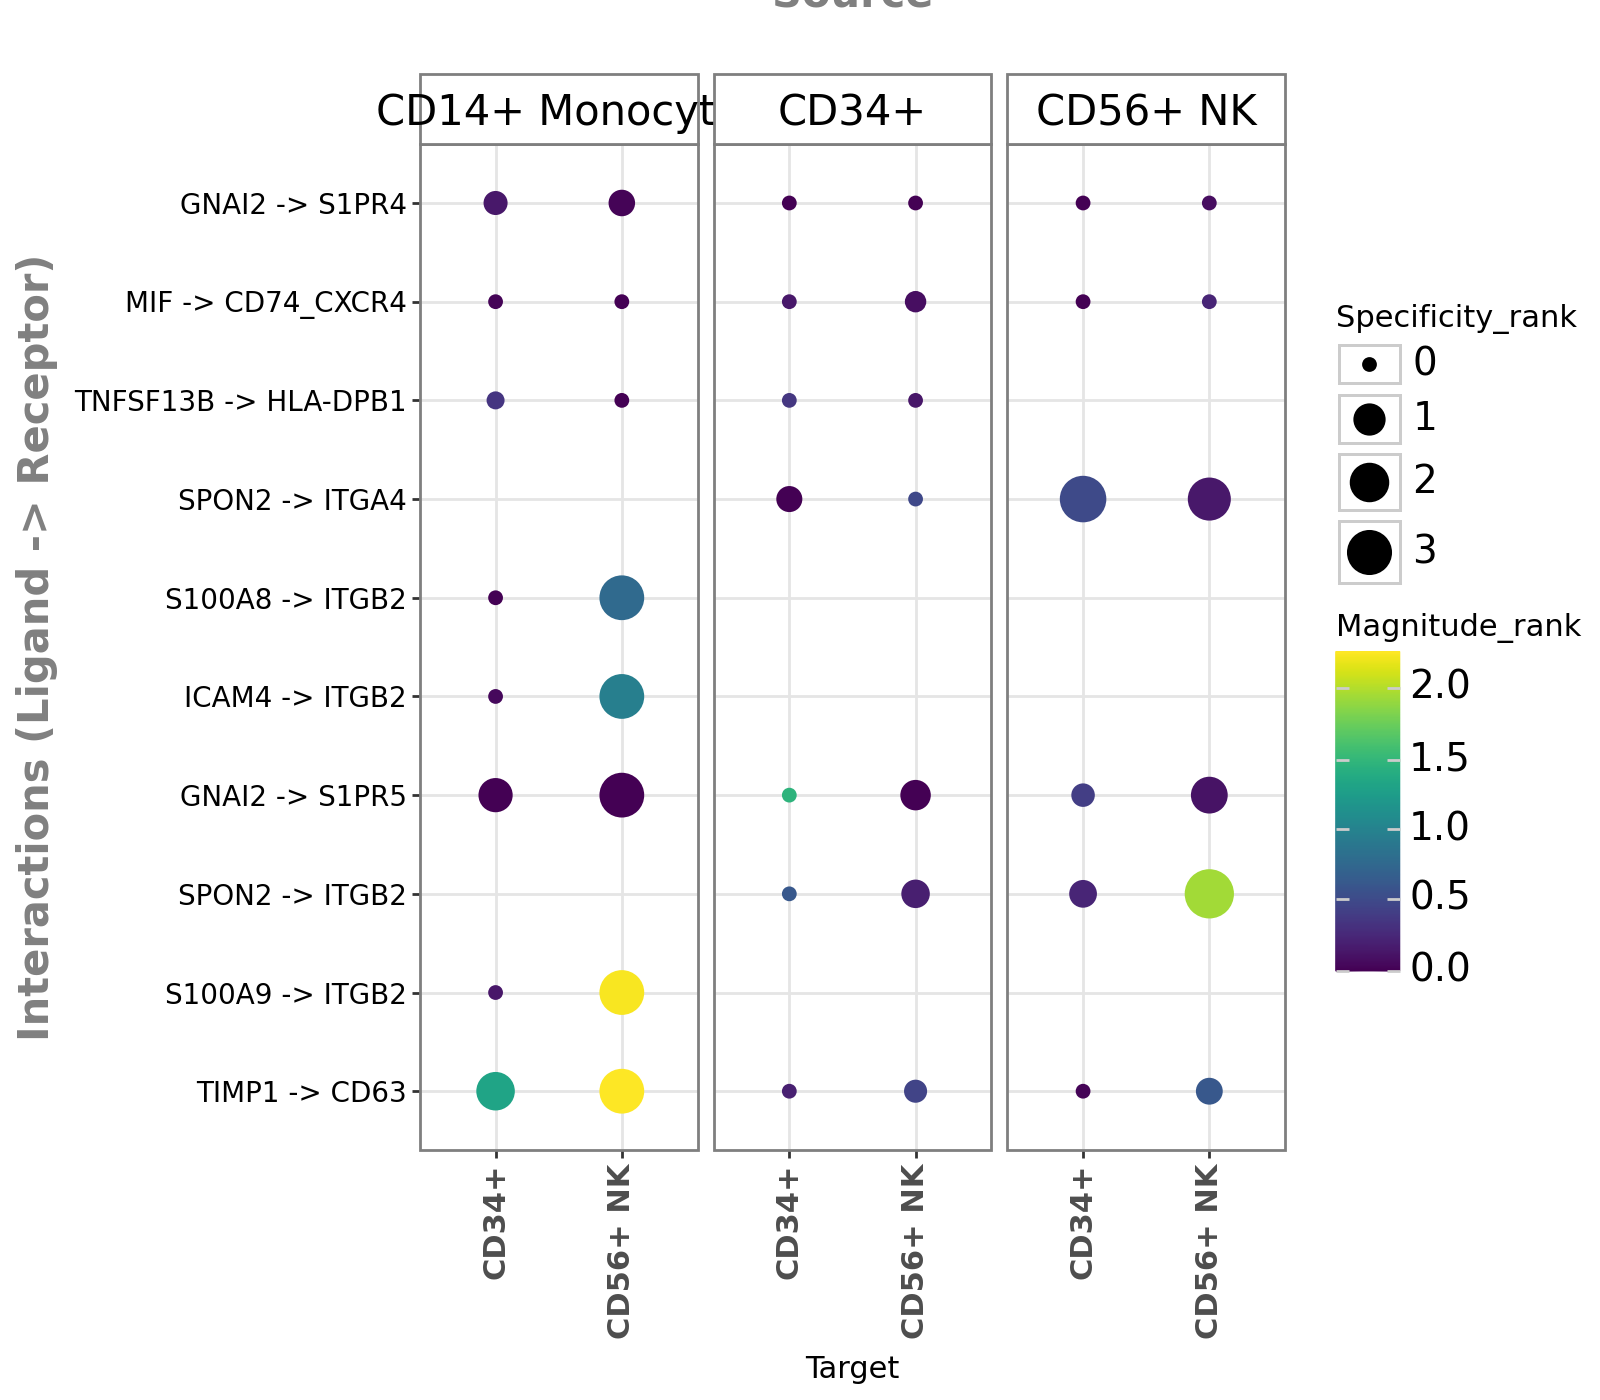

In [ ]:
li.pl.dotplot(adata = adata,
              colour='magnitude_rank',
              size='specificity_rank',
              inverse_size=True,
              inverse_colour=True,
              source_labels=['CD34+', 'CD56+ NK', 'CD14+ Monocyte'],
              target_labels=['CD34+', 'CD56+ NK'],
              top_n=10,
              orderby='magnitude_rank',
              orderby_ascending=True,
              figure_size=(8, 7)
             )

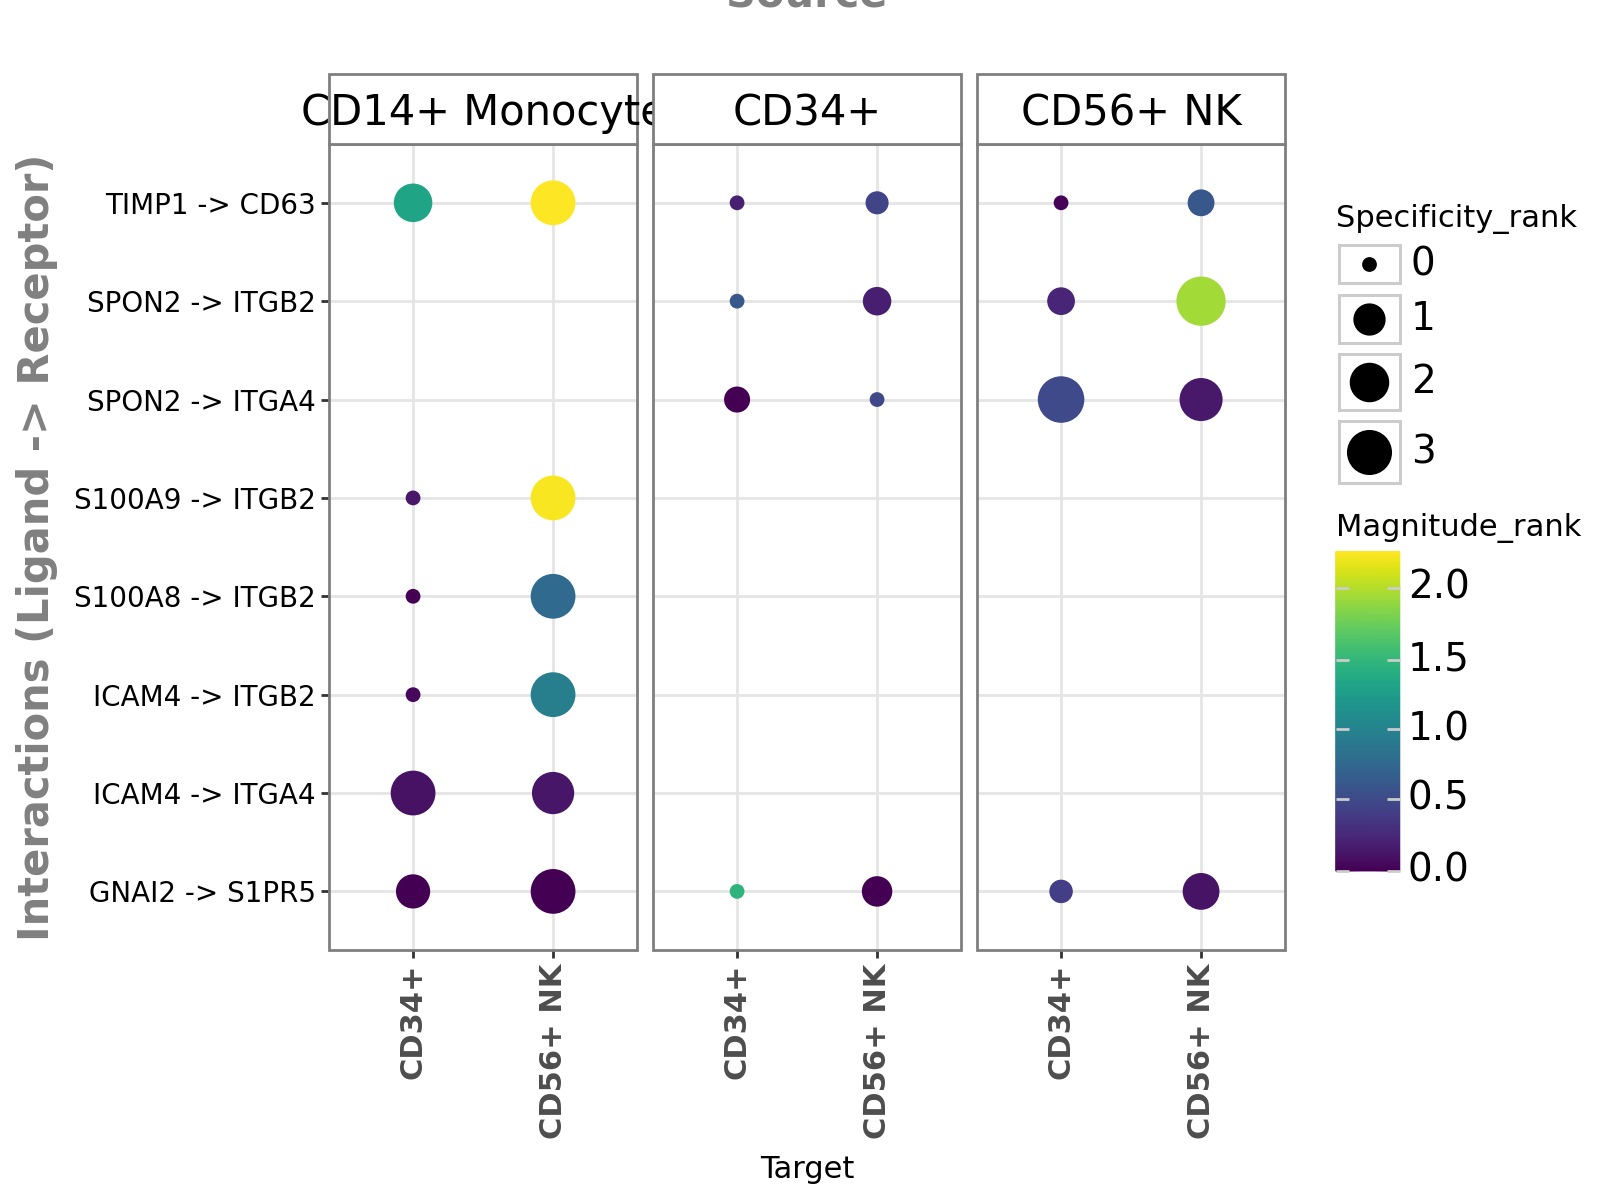

In [ ]:
my_plot = li.pl.dotplot(adata = adata,
                        colour='magnitude_rank',
                        inverse_colour=True,
                        size='specificity_rank',
                        inverse_size=True,
                        source_labels=['CD34+', 'CD56+ NK', 'CD14+ Monocyte'],
                        target_labels=['CD34+', 'CD56+ NK'],
                        filter_fun=lambda x: x['specificity_rank'] <= 0.01,
                       )
my_plot

In [ ]:
# we import plotnine
import plotnine as p9

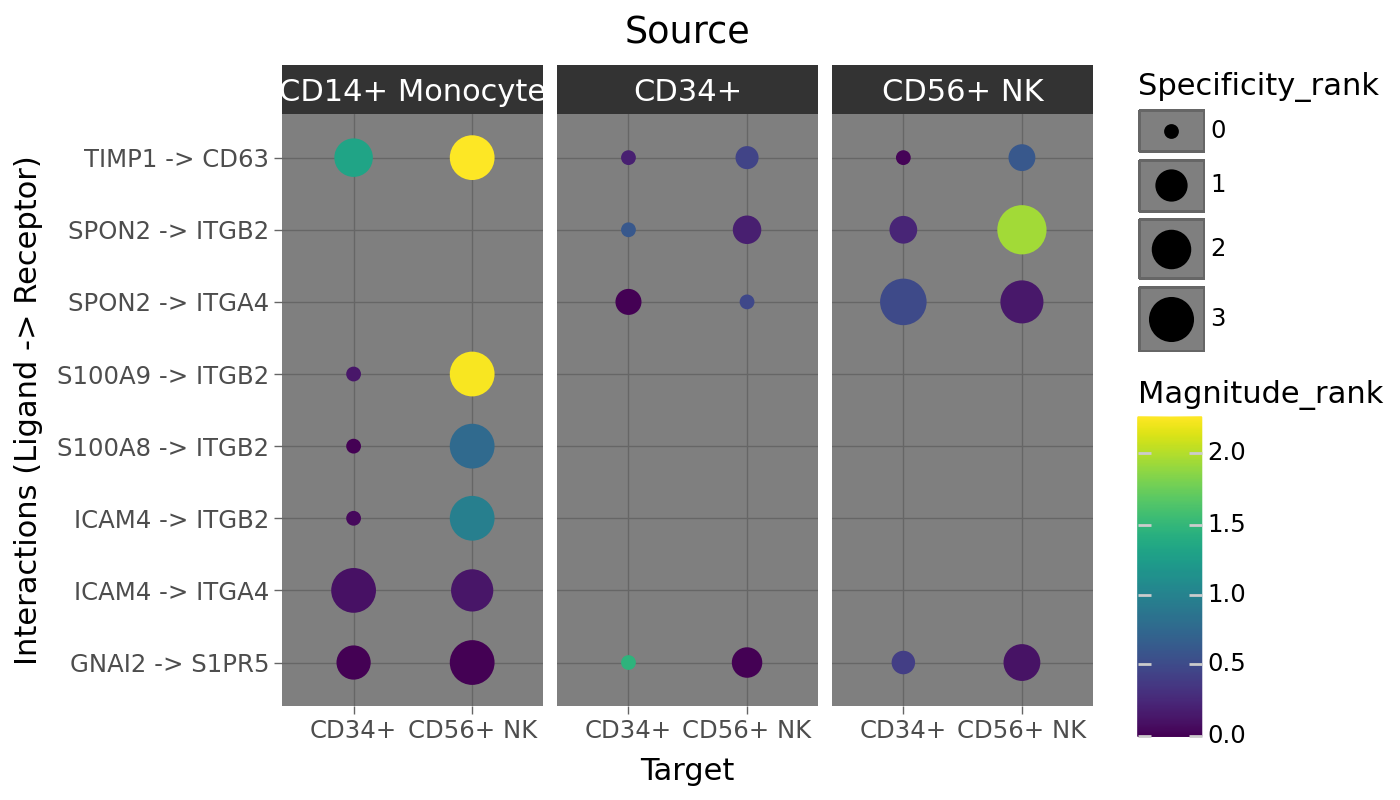

In [ ]:
(my_plot +
 # change theme
 p9.theme_dark() +
 # modify theme
 p9.theme(
     # adjust facet size
     strip_text=p9.element_text(size=11),
     figure_size=(7, 4)
 )
)

<Axes: >

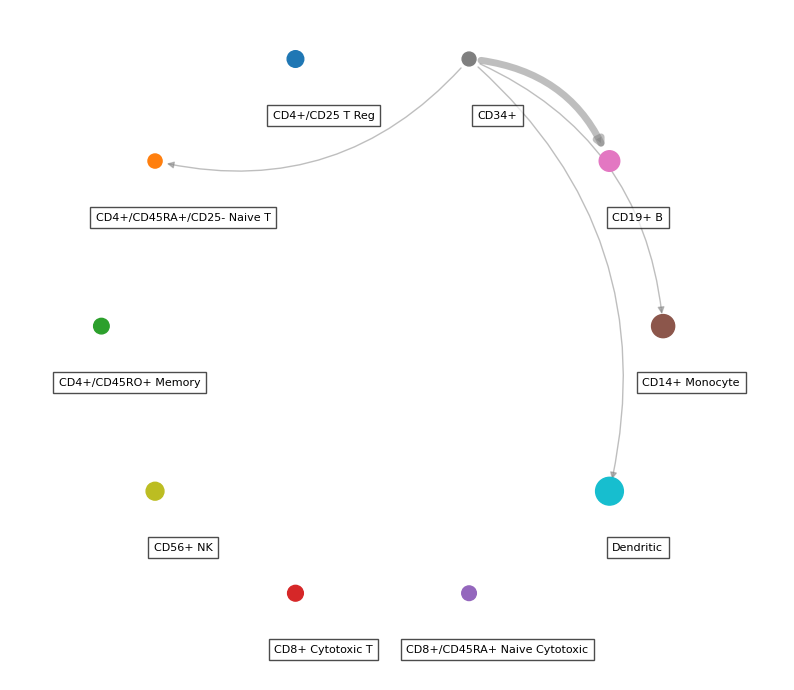

In [ ]:
li.pl.circle_plot(adata,
                  groupby='bulk_labels',
                  score_key='magnitude_rank',
                  inverse_score=True,
                  source_labels='CD34+',
                  filter_fun=lambda x: x['specificity_rank'] <= 0.05,
                  pivot_mode='counts', # NOTE: this will simply count the interactions, 'mean' is also available
                  figure_size=(10, 10),
                  )

In [ ]:
methods = [logfc, geometric_mean]
new_rank_aggregate = li.mt.AggregateClass(li.mt.aggregate_meta, methods=methods)

In [ ]:
new_rank_aggregate(adata,
                   groupby='bulk_labels',
                   expr_prop=0.1,
                   verbose=True,
                   # Note that with this option, we don't perform permutations
                   # and hence we exclude the p-value for geometric_mean, as well as specificity_rank
                   n_perms=None,
                   use_raw=True,
                   )

/usr/local/lib/python3.12/dist-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/usr/local/lib/python3.12/dist-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


Generating ligand-receptor stats for 700 samples and 43 features
Assuming that counts were `natural` log-normalized!


/usr/local/lib/python3.12/dist-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
/usr/local/lib/python3.12/dist-packages/liana/method/sc/_liana_pipe.py:296: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
/usr/local/lib/python3.12/dist-packages/liana/method/sc/_liana_pipe.py:298: ImplicitModificationWarning: Setting element `.layers['normcounts']` of view, initializing view as actual.


Running log2FC
Running Geometric Mean


In [ ]:
adata.uns['liana_res'].head()

,source,target,ligand_complex,receptor_complex,lr_logfc,lr_gmeans,magnitude_rank
110,CD14+ Monocyte,CD56+ NK,TIMP1,CD63,1.435272,2.126363,0.000776
109,CD14+ Monocyte,CD56+ NK,S100A9,ITGB2,1.069681,2.048953,0.001553
20,CD14+ Monocyte,CD14+ Monocyte,S100A9,ITGB2,1.069747,1.979752,0.002329
838,CD56+ NK,CD56+ NK,SPON2,ITGB2,1.860055,1.926317,0.003106
782,CD56+ NK,CD14+ Monocyte,SPON2,ITGB2,1.860121,1.861258,0.003882


Prior Knowledge

In [ ]:
!pip install omnipath
!pip install decoupler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 kB 2.8 MB/s eta 0:00:00


In [ ]:
import omnipath as op
import decoupler as dc

In [ ]:
li.resource.show_resources()

['baccin2019',
 'cellcall',
 'cellchatdb',
 'cellinker',
 'cellphonedb',
 'celltalkdb',
 'connectomedb2020',
 'consensus',
 'embrace',
 'guide2pharma',
 'hpmr',
 'icellnet',
 'italk',
 'kirouac2010',
 'lrdb',
 'mouseconsensus',
 'ramilowski2015']

In [ ]:
resource = li.rs.select_resource('consensus')
resource.head()

,ligand,receptor
0,LGALS9,PTPRC
1,LGALS9,MET
2,LGALS9,CD44
3,LGALS9,LRP1
4,LGALS9,CD47


In [ ]:
ligrec = op.interactions.import_intercell_network(
    interactions_params = {'license':'commercial'},
    transmitter_params = {'database':'CellChatDB'},
    receiver_params = {'database':'CellChatDB'},
    )
ligrec.head()

ligrec = ligrec.rename(columns={'genesymbol_intercell_source':'ligand', 'genesymbol_intercell_target':'receptor'})
ligrec = ligrec[['ligand', 'receptor', 'references'] + [col for col in ligrec.columns if col not in ['ligand', 'receptor', 'references']]]
ligrec.head()

0.00B [00:00, ?B/s]

0.00B [00:00, ?B/s]

0.00B [00:00, ?B/s]

,ligand,receptor,references,source,target,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition,...,aspect_intercell_target,category_source_intercell_target,uniprot_intercell_target,entity_type_intercell_target,consensus_score_intercell_target,transmitter_intercell_target,receiver_intercell_target,secreted_intercell_target,plasma_membrane_transmembrane_intercell_target,plasma_membrane_peripheral_intercell_target
0,JAG2,NOTCH1,SPIKE:11006133;connectomeDB2020:11006133;SPIKE...,Q9Y219,P46531,True,True,True,True,False,...,functional,resource_specific,P46531,protein,22,False,True,False,True,False
1,DLL1,NOTCH1,SPIKE:11006133;connectomeDB2020:11006133;Celli...,O00548,P46531,True,False,True,True,False,...,functional,resource_specific,P46531,protein,22,False,True,False,True,False
2,IGF1,IGF1R,HPRD:1852007;SignaLink3:23331499;SignaLink3:12...,P05019,P08069,True,False,True,True,False,...,functional,resource_specific,P08069,protein,20,False,True,False,True,False
3,WNT1,NOTCH1,SPIKE_LC:18495817;SPIKE:18495817,P04628,P46531,True,False,True,True,False,...,functional,resource_specific,P46531,protein,22,False,True,False,True,False
4,JAG1,NOTCH1,SPIKE:11006133;SPIKE:18495817;connectomeDB2020...,P78504,P46531,True,True,True,True,False,...,functional,resource_specific,P46531,protein,22,False,True,False,True,False


In [ ]:
# let's say we are interested in zebrafish homologs of human genes
map_df = li.rs.get_hcop_orthologs(url='https://ftp.ebi.ac.uk/pub/databases/genenames/hcop/human_zebrafish_hcop_fifteen_column.txt.gz',
                                   columns=['human_symbol', 'zebrafish_symbol'],
                                   # NOTE: HCOP integrates multiple resource, so we can filter out mappings in at least 3 of them for confidence
                                   min_evidence=3
                                   )
# rename the columns to source and target, respectively for the original organism and the target organism
map_df = map_df.rename(columns={'human_symbol':'source', 'zebrafish_symbol':'target'})
map_df.tail()

/usr/local/lib/python3.12/dist-packages/liana/resource/_orthology.py:204: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


,source,target
132672,ZYG11B,zyg11
132673,ZYG11B,zyg11l
132674,ZYX,zyx
132676,ZZEF1,zzef1
132677,ZZZ3,zzz3


In [ ]:
zfish = li.rs.translate_resource(resource,
                                 map_df=map_df,
                                 columns=['ligand', 'receptor'],
                                 replace=True,
                                 # NOTE that we need to define the threshold of redundancies for the mapping
                                 # in this case, we would keep mappings as long as they don't map to more than 2 zebrafish genes
                                 one_to_many=3
                                 )

In [ ]:
map_df = li.rs.get_hcop_orthologs(url='https://ftp.ebi.ac.uk/pub/databases/genenames/hcop/human_mouse_hcop_fifteen_column.txt.gz',
                                  columns=['human_symbol', 'mouse_symbol'],
                                   # NOTE: HCOP integrates multiple resource, so we can filter out mappings in at least 3 of them for confidence
                                   min_evidence=3
                                   )
# rename the columns to source and target, respectively for the original organism and the target organism
map_df = map_df.rename(columns={'human_symbol':'source', 'mouse_symbol':'target'})

# We will then translate
mouse = li.rs.translate_resource(resource,
                                 map_df=map_df,
                                 columns=['ligand', 'receptor'],
                                 replace=True,
                                 # Here, we will be harsher and only keep mappings that don't map to more than 1 mouse gene
                                 one_to_many=1
                                 )
mouse

/usr/local/lib/python3.12/dist-packages/liana/resource/_orthology.py:204: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


,ligand,receptor
0,Lgals9,Ptprc
1,Lgals9,Met
2,Lgals9,Cd44
3,Lgals9,Lrp1
4,Lgals9,Cd47
...,...,...
4619,Bmp2,Actr2
4620,Bmp15,Actr2
4621,Csf1,Csf3r
4622,Il36g,Ifnar1


In [ ]:
# load PROGENy pathways, we use decoupler as a proxy as it formats the data in a more convenient way
progeny = dc.op.progeny(top=2500)
progeny.head()

,source,target,weight,padj
0,Androgen,TMPRSS2,11.490631,2.384806e-47
1,Androgen,NKX3-1,10.622551,2.205102e-44
2,Androgen,MBOAT2,10.472733,4.632376e-44
3,Androgen,KLK2,10.176186,1.944410e-40
4,Androgen,SARG,11.386852,2.790210e-40


In [ ]:
# load full list of ligand-receptor pairs
lr_pairs = li.resource.select_resource('consensus')

In [ ]:
# generate ligand-receptor geneset
lr_progeny = li.rs.generate_lr_geneset(lr_pairs, progeny, lr_sep="^")
lr_progeny.head()

,source,interaction,weight
4,JAK-STAT,LGALS9^CD47,2.054778
15,JAK-STAT,LGALS9^HAVCR2,1.487678
34,EGFR,ADAM10^TSPAN12,-1.275034
57,VEGF,TNFSF11^TNFRSF11A,2.571622
98,JAK-STAT,TNFSF13^TNFRSF1A,0.788753


In [ ]:
diseases = op.requests.Annotations.get(
    resources = ['DisGeNet']
    )

0.00B [00:00, ?B/s]

In [ ]:
diseases = diseases[['genesymbol', 'label', 'value']]
diseases = diseases.pivot_table(index='genesymbol',
                                columns='label', values='value',
                                aggfunc=lambda x: '; '.join(x)).reset_index()
diseases = diseases[['genesymbol', 'disease']]
diseases['disease'] = diseases['disease'].str.split('; ')
diseases = diseases.explode('disease')
lr_diseases = li.rs.generate_lr_geneset(lr_pairs, diseases, source='disease', target='genesymbol', weight=None, lr_sep="^")
lr_diseases.sort_values("interaction").head()

/tmp/ipython-input-463/3054253547.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior


,disease,interaction
142540,Stomach Neoplasms,ACE^AGTR2
141855,Hereditary Diffuse Gastric Cancer,ACE^AGTR2
141886,Hypertensive disease,ACE^AGTR2
141993,Left Ventricular Hypertrophy,ACE^AGTR2
142616,Vascular System Injuries,ACE^AGTR2


In [ ]:
ppis = op.interactions.OmniPath().get(genesymbols = True)
ppis.head()

0.00B [00:00, ?B/s]

,source,target,source_genesymbol,target_genesymbol,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition,sources,references,curation_effort,n_sources,n_primary_sources,n_references,references_stripped
0,P0DP25,P48995,CALM3,TRPC1,True,False,True,True,False,True,TRIP,TRIP:11290752;TRIP:11983166;TRIP:12601176,3,1,1,3,11290752;11983166;12601176
1,P0DP23,P48995,CALM1,TRPC1,True,False,True,True,False,True,TRIP,TRIP:11290752;TRIP:11983166;TRIP:12601176,3,1,1,3,11290752;11983166;12601176
2,P0DP24,P48995,CALM2,TRPC1,True,False,True,True,False,True,TRIP,TRIP:11290752;TRIP:11983166;TRIP:12601176,3,1,1,3,11290752;11983166;12601176
3,Q03135,P48995,CAV1,TRPC1,True,True,False,True,True,False,TRIP;HINT;HPRD;DIP;Lit-BM-17;IntAct,TRIP:14551243;TRIP:18430726;TRIP:19052258;HINT...,15,6,6,8,10980191;12732636;14551243;16822931;18430726;1...
4,P14416,P48995,DRD2,TRPC1,True,True,False,True,True,False,TRIP,TRIP:18261457,1,1,1,1,18261457


In [ ]:
dc.op.collectri(organism='human', remove_complexes=False, license='academic', verbose=False).head()

,source,target,weight,resources,references,sign_decision
0,MYC,TERT,1.0,DoRothEA-A;ExTRI;HTRI;NTNU.Curated;Pavlidis202...,10022128;10491298;10606235;10637317;10723141;1...,PMID
1,SPI1,BGLAP,1.0,ExTRI,10022617,default activation
2,SMAD3,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
3,SMAD4,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
4,STAT5A,IL2,1.0,ExTRI,10022878;11435608;17182565;17911616;22854263;2...,default activation


In [ ]:
li.resource.get_metalinks_values(table_name='disease', column_name='disease')[0:5]

['Molybdenum cofactor deficiency',
 'Metastatic melanoma',
 'Schizophrenia',
 'Anoxia',
 'Colorectal cancer']

In [ ]:
li.resource.get_metalinks(source=['Stich', 'CellPhoneDB', 'NeuronChat'],
                          tissue_location='Brain',
                          biospecimen_location='Cerebrospinal Fluid (CSF)',
                          disease='Schizophrenia',
                          ).head()

,hmdb,uniprot,gene_symbol,metabolite,mor,transport_direction,type,source
0,HMDB0000234,P10275,AR,Testosterone,-1,None,lr,CellPhoneDB
1,HMDB0000234,P10275,AR,Testosterone,0,None,lr,CellPhoneDB
2,HMDB0000234,P10275,AR,Testosterone,1,None,lr,CellPhoneDB
3,HMDB0000073,A5X5Y0,HTR3E,Dopamine,1,None,lr,CellPhoneDB
4,HMDB0000073,O95264,HTR3B,Dopamine,1,None,lr,CellPhoneDB


In [ ]:
li.rs.describe_metalinks()

Schema of table: metabolites
Column ID: 0, Name: hmdb, Type: TEXT, Primary Key: 0
Column ID: 1, Name: metabolite, Type: TEXT, Primary Key: 0
Column ID: 2, Name: pubchem, Type: TEXT, Primary Key: 0
Column ID: 3, Name: metabolite_subclass, Type: TEXT, Primary Key: 0

No Foreign Keys.
----------------------------------------
Schema of table: proteins
Column ID: 0, Name: uniprot, Type: TEXT, Primary Key: 0
Column ID: 1, Name: gene_symbol, Type: TEXT, Primary Key: 0
Column ID: 2, Name: protein_type, Type: TEXT, Primary Key: 0

No Foreign Keys.
----------------------------------------
Schema of table: edges
Column ID: 0, Name: hmdb, Type: TEXT, Primary Key: 0
Column ID: 1, Name: uniprot, Type: TEXT, Primary Key: 0
Column ID: 2, Name: source, Type: TEXT, Primary Key: 0
Column ID: 3, Name: db_score, Type: REAL, Primary Key: 0
Column ID: 4, Name: experiment_score, Type: REAL, Primary Key: 0
Column ID: 5, Name: combined_score, Type: REAL, Primary Key: 0
Column ID: 6, Name: mor, Type: INTEGER, Pr

Testing if Seurat data loads into ScanPy

In [ ]:
import pandas as pd
import scanpy as sc

In [ ]:
# from google.colab import files
# uploaded = files.upload()

In [ ]:
data = sc.read_h5ad()